# CSP Baseline Cross-Subject Tuning Study

## Project Context

This notebook performs a controlled tuning study of the original **CSP + LDA** baseline on the same dataset and cross-subject evaluation setting used in the project.

The model family stays fixed. Only two parameters are tuned:
- frequency band
- CSP component count

The goal is to test whether simple baseline tuning improves cross-subject performance, especially for the low-performing subjects identified earlier (2, 5, 6).

# 1. Environment and Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import builtins
import json
import re
import sys
import time
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
import mne
import moabb

from moabb.datasets import BNCI2014_001
from moabb.paradigms import LeftRightImagery
from moabb.evaluations import CrossSubjectEvaluation

from mne.decoding import CSP

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.pipeline import make_pipeline

SEED = 42
np.random.seed(SEED)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_style('whitegrid')

print('=' * 60)
print('PACKAGE VERSIONS')
print('=' * 60)
print(f'Python: {sys.version.split()[0]}')
print(f'numpy: {np.__version__}')
print(f'pandas: {pd.__version__}')
print(f'matplotlib: {plt.matplotlib.__version__}')
print(f'seaborn: {sns.__version__}')
print(f'sklearn: {sklearn.__version__}')
print(f'mne: {mne.__version__}')
print(f'moabb: {moabb.__version__}')

PACKAGE VERSIONS
Python: 3.13.3
numpy: 2.4.3
pandas: 3.0.1
matplotlib: 3.10.8
seaborn: 0.13.2
sklearn: 1.8.0
mne: 1.11.0
moabb: 1.4.3


In [2]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
ARTIFACT_DIR = BASE_DIR / 'artifacts' / '03c_csp_band_tuning'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Artifact directory: {ARTIFACT_DIR}')

Artifact directory: /home/vegorov/Repos/bci-inefficiency-analysis/src/artifacts/03c_csp_band_tuning


In [3]:
LOG_PATH = ARTIFACT_DIR / 'run.log'
if '_LOG_FILE_HANDLE' in globals() and _LOG_FILE_HANDLE and not _LOG_FILE_HANDLE.closed:
    _LOG_FILE_HANDLE.close()
_LOG_FILE_HANDLE = open(LOG_PATH, 'w', buffering=1, encoding='utf-8')

def _timestamped_print(*args, **kwargs):
    sep = kwargs.pop('sep', ' ')
    end = kwargs.pop('end', '\n')
    flush = kwargs.pop('flush', False)
    file = kwargs.pop('file', None)

    message = sep.join(str(arg) for arg in args)
    leading_newlines = len(message) - len(message.lstrip('\n'))
    message_body = message[leading_newlines:]

    def _write_target(text):
        if file is None:
            sys.__stdout__.write(text)
            if flush:
                sys.__stdout__.flush()
        else:
            file.write(text)
            if flush and hasattr(file, 'flush'):
                file.flush()

    if leading_newlines > 0:
        blanks = '\n' * leading_newlines
        _write_target(blanks)
        _LOG_FILE_HANDLE.write(blanks)

    if message_body:
        ts = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        stamped = f'[{ts}] {message_body}'
        _write_target(stamped + end)
        _LOG_FILE_HANDLE.write(stamped + end)
    else:
        _write_target(end)
        _LOG_FILE_HANDLE.write(end)

    if flush:
        _LOG_FILE_HANDLE.flush()

builtins.print = _timestamped_print

print(f'Logging to: {LOG_PATH}')

[2026-04-15 16:20:33] Logging to: /home/vegorov/Repos/bci-inefficiency-analysis/src/artifacts/03c_csp_band_tuning/run.log


In [4]:
def save_plot(filename):
    path = ARTIFACT_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Saved plot: {path}')

def save_table(data, filename, index=False):
    path = ARTIFACT_DIR / filename
    suffix = path.suffix.lower()

    if suffix == '.csv':
        if isinstance(data, pd.Series):
            data = data.to_frame()
        data.to_csv(path, index=index)
    elif suffix == '.json':
        if isinstance(data, pd.DataFrame):
            data.to_json(path, orient='records', indent=2)
        else:
            with open(path, 'w', encoding='utf-8') as f:
                json.dump(data, f, indent=2)
    else:
        raise ValueError(f'Unsupported table extension: {suffix}')

    print(f'Saved table: {path}')

def get_first_matching_column(frame, candidates):
    lower_lookup = {column.lower(): column for column in frame.columns}
    for candidate in candidates:
        if candidate in frame.columns:
            return candidate
        lowered = candidate.lower()
        if lowered in lower_lookup:
            return lower_lookup[lowered]
    raise KeyError(f'Expected one of {candidates}; available columns: {list(frame.columns)}')

def normalize_subject_value(value):
    if isinstance(value, (int, np.integer)):
        return int(value)
    if isinstance(value, float) and float(value).is_integer():
        return int(value)
    text = str(value)
    match = re.search(r'\d+', text)
    return int(match.group()) if match else np.nan

def make_config_name(low, high, n_components):
    return f'band_{low}_{high}__csp_{n_components}'

# 2. Dataset, Paradigm, and Tuning Configuration

In [5]:
dataset = BNCI2014_001()
base_paradigm = LeftRightImagery()

BANDS = [
    (8, 30),
    (8, 32),
    (8, 35),
    (10, 30),
    (12, 30),
]
CSP_COMPONENTS = [4, 6, 8, 10, 12, 14]
LOW_SUBJECTS = [2, 5]
TOTAL_CONFIGS = len(BANDS) * len(CSP_COMPONENTS)

print('Dataset and baseline paradigm initialized.')
print(f'Dataset: {dataset.__class__.__name__}')
print(f'Paradigm: {base_paradigm.__class__.__name__}')

print('\n' + '=' * 60)
print('DATASET INFORMATION')
print('=' * 60)
print(f'Number of subjects: {len(dataset.subject_list)}')
print(f'Subject IDs: {dataset.subject_list}')
print(f'Number of sessions: {dataset.n_sessions}')
print(f'Event IDs (all classes): {dataset.event_id}')

print('\n' + '=' * 60)
print('TUNING GRID')
print('=' * 60)
print(f'Bands: {BANDS}')
print(f'CSP components: {CSP_COMPONENTS}')
print(f'Low-performing subjects of interest: {LOW_SUBJECTS}')
print(f'Total configurations: {TOTAL_CONFIGS}')
print(f'Base paradigm events: {base_paradigm.events}')
print(f'Base paradigm filters: {base_paradigm.filters}')

[2026-04-15 16:20:33] Dataset and baseline paradigm initialized.
[2026-04-15 16:20:33] Dataset: BNCI2014_001
[2026-04-15 16:20:33] Paradigm: LeftRightImagery

[2026-04-15 16:20:33] ============================================================
[2026-04-15 16:20:33] DATASET INFORMATION
[2026-04-15 16:20:33] ============================================================
[2026-04-15 16:20:33] Number of subjects: 9
[2026-04-15 16:20:33] Subject IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9]
[2026-04-15 16:20:33] Number of sessions: 2
[2026-04-15 16:20:33] Event IDs (all classes): {'left_hand': 1, 'right_hand': 2, 'feet': 3, 'tongue': 4}

[2026-04-15 16:20:33] ============================================================
[2026-04-15 16:20:33] TUNING GRID
[2026-04-15 16:20:33] ============================================================
[2026-04-15 16:20:33] Bands: [(8, 30), (8, 32), (8, 35), (10, 30), (12, 30)]
[2026-04-15 16:20:33] CSP components: [4, 6, 8, 10, 12, 14]
[2026-04-15 16:20:33] Low-performing su

# 3. Cross-Subject Evaluation Setup

In [6]:
from sklearn.base import BaseEstimator, TransformerMixin
from mne.filter import filter_data

# Filtering mode options:
# - 'paradigm_fir' : MOABB paradigm applies bandpass via fmin/fmax (default behavior).
# - 'pipeline_iir': explicit IIR bandpass is applied in the sklearn pipeline.
FILTERING_MODE = 'pipeline_iir'

# Parameters used only when FILTERING_MODE == 'pipeline_iir'.
IIR_SFREQ = 250.0
IIR_PARAMS = {'order': 4, 'ftype': 'butter'}

# Recommended default: refresh MOABB cache when changing filtering backend.
DEFAULT_EVAL_OVERWRITE = FILTERING_MODE == 'pipeline_iir'


class IIRBandpassFilter(BaseEstimator, TransformerMixin):
    def __init__(self, l_freq, h_freq, sfreq=250.0, iir_params=None):
        self.l_freq = l_freq
        self.h_freq = h_freq
        self.sfreq = sfreq
        self.iir_params = iir_params if iir_params is not None else {'order': 4, 'ftype': 'butter'}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=np.float64)
        return filter_data(
            X,
            sfreq=self.sfreq,
            l_freq=self.l_freq,
            h_freq=self.h_freq,
            method='iir',
            iir_params=self.iir_params,
            verbose=False,
        )


def build_csp_lda_pipeline(n_components, low=None, high=None):
    if FILTERING_MODE == 'pipeline_iir':
        if low is None or high is None:
            raise ValueError('low/high must be provided when FILTERING_MODE is pipeline_iir')
        return make_pipeline(
            IIRBandpassFilter(l_freq=low, h_freq=high, sfreq=IIR_SFREQ, iir_params=IIR_PARAMS),
            CSP(n_components=n_components, reg=None, log=True, norm_trace=False),
            LDA(solver='lsqr', shrinkage='auto'),
        )

    return make_pipeline(
        CSP(n_components=n_components, reg=None, log=True, norm_trace=False),
        LDA(solver='lsqr', shrinkage='auto'),
    )


def run_cross_subject_for_config(dataset, low, high, n_components, overwrite=False):
    config_name = make_config_name(low, high, n_components)

    if FILTERING_MODE == 'pipeline_iir':
        # Disable paradigm bandpass and apply explicit IIR in the pipeline.
        paradigm_cfg = LeftRightImagery()
    else:
        # MOABB LeftRightImagery expects fmin/fmax in this environment.
        paradigm_cfg = LeftRightImagery(fmin=low, fmax=high)

    evaluation_cfg = CrossSubjectEvaluation(
        paradigm=paradigm_cfg,
        datasets=[dataset],
        overwrite=overwrite,
    )

    pipeline = build_csp_lda_pipeline(n_components=n_components, low=low, high=high)
    pipelines = {config_name: pipeline}

    start = time.time()
    raw_results = evaluation_cfg.process(pipelines)
    elapsed = time.time() - start

    score_col = get_first_matching_column(raw_results, ['score', 'scores', 'accuracy'])
    subject_col = get_first_matching_column(raw_results, ['subject', 'subjects', 'subject_id'])

    return raw_results, elapsed, score_col, subject_col, config_name

# 4. Run Tuning Sweep

In [7]:
all_results_frames = []
config_summary_rows = []
per_subject_rows = []

config_counter = 0

for (low, high) in BANDS:
    for n_components in CSP_COMPONENTS:
        config_counter += 1
        config_name = make_config_name(low, high, n_components)
        band_label = f'{low}-{high}'

        print('\n' + '=' * 60)
        print(f'RUNNING CONFIG {config_counter}/{TOTAL_CONFIGS}: {config_name}')
        print('=' * 60)

        raw_results, elapsed_sec, score_col, subject_col, returned_config_name = run_cross_subject_for_config(
            dataset=dataset,
            low=low,
            high=high,
            n_components=n_components,
            overwrite=DEFAULT_EVAL_OVERWRITE,
        )

        raw_results = raw_results.copy()
        raw_results['band_low'] = low
        raw_results['band_high'] = high
        raw_results['band_label'] = band_label
        raw_results['n_components'] = n_components
        raw_results['config_name'] = returned_config_name
        raw_results['subject_norm'] = raw_results[subject_col].map(normalize_subject_value)
        all_results_frames.append(raw_results)

        mean_score = float(raw_results[score_col].mean())
        std_score = float(raw_results[score_col].std())
        min_score = float(raw_results[score_col].min())
        max_score = float(raw_results[score_col].max())

        per_subject_means = raw_results.groupby(subject_col)[score_col].mean().reset_index(name='score')
        per_subject_means['subject_norm'] = per_subject_means[subject_col].map(normalize_subject_value)
        per_subject_means['band_low'] = low
        per_subject_means['band_high'] = high
        per_subject_means['band_label'] = band_label
        per_subject_means['n_components'] = n_components
        per_subject_means['config_name'] = returned_config_name

        for _, row in per_subject_means.iterrows():
            per_subject_rows.append({
                'subject': row[subject_col],
                'subject_norm': row['subject_norm'],
                'band_low': low,
                'band_high': high,
                'band_label': band_label,
                'n_components': n_components,
                'config_name': returned_config_name,
                'score': float(row['score']),
            })

        bottom2_mask = per_subject_means['subject_norm'].isin(LOW_SUBJECTS)
        bottom2_mean_score = float(per_subject_means.loc[bottom2_mask, 'score'].mean()) if bottom2_mask.any() else np.nan

        config_summary_rows.append({
            'band_low': low,
            'band_high': high,
            'band_label': band_label,
            'n_components': n_components,
            'config_name': returned_config_name,
            'mean_score': mean_score,
            'std_score': std_score,
            'min_score': min_score,
            'max_score': max_score,
            'elapsed_sec': float(elapsed_sec),
            'bottom2_mean_score': bottom2_mean_score,
        })

        print(f'Results shape: {raw_results.shape}')
        print(f'Results columns: {list(raw_results.columns)}')
        print(f'Elapsed (sec): {elapsed_sec:.2f}')
        print(f'Mean score: {mean_score:.4f}')
        print(f'Std score: {std_score:.4f}')
        print(f'Min score: {min_score:.4f}')
        print(f'Max score: {max_score:.4f}')
        if not np.isnan(bottom2_mean_score):
            print(f'Bottom-2 mean score (subjects {LOW_SUBJECTS}): {bottom2_mean_score:.4f}')

all_results_df = pd.concat(all_results_frames, ignore_index=True)
config_summary_df = pd.DataFrame(config_summary_rows)
per_subject_df = pd.DataFrame(per_subject_rows)

print('\n' + '=' * 60)
print('SWEEP COMPLETE')
print('=' * 60)
print(f'Combined raw results shape: {all_results_df.shape}')
print(f'Config summary shape: {config_summary_df.shape}')
print(f'Per-subject summary shape: {per_subject_df.shape}')


[2026-04-15 16:20:33] ============================================================
[2026-04-15 16:20:33] RUNNING CONFIG 1/30: band_8_30__csp_4
[2026-04-15 16:20:33] ============================================================


100%|█████████████████████████████████████| 42.8M/42.8M [00:00<00:00, 92.1GB/s]
SHA256 hash of downloaded file: 054f02e70cf9c4ada1517e9b9864f45407939c1062c6793516585c6f511d0325
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
100%|█████████████████████████████████████| 43.8M/43.8M [00:00<00:00, 66.8GB/s]
SHA256 hash of downloaded file: 53d415f39c3d7b0c88b894d7b08d99bcdfe855ede63831d3691af1a45607fb62
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
100%|█████████████████████████████████████| 43.1M/43.1M [00:00<00:00, 67.6GB/s]
SHA256 hash of downloaded file: 5ddd5cb520b1692c3ba1363f48d98f58f0e46f3699ee50d749947950fc39db27
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
100%|████████████████████████████████

Computing rank from data with rank=None
    Using tolerance 1.8e+02 (2.2e-16 eps * 22 dim * 3.7e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


BNCI2014-001-CrossSubject:  11%|█         | 1/9 [00:09<01:17,  9.71s/it]

Computing rank from data with rank=None
    Using tolerance 1.7e+02 (2.2e-16 eps * 22 dim * 3.6e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


...

Computing rank from data with rank=None
    Using tolerance 1.2e+02 (2.2e-16 eps * 22 dim * 2.5e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


BNCI2014-001-CrossSubject:  89%|████████▉ | 8/9 [01:16<00:09,  9.54s/it]

Computing rank from data with rank=None
    Using tolerance 1.3e+02 (2.2e-16 eps * 22 dim * 2.7e+16  max singular value)
    Estimated rank (data): 22
    data: rank 22 computed from 22 data channels with 0 projectors
Reducing data rank from 22 -> 22
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


BNCI2014-001-CrossSubject: 100%|██████████| 9/9 [01:26<00:00,  9.59s/it]


[2026-04-15 17:12:18] Results shape: (18, 15)
[2026-04-15 17:12:18] Results columns: ['score', 'time', 'samples', 'subject', 'session', 'channels', 'n_sessions', 'dataset', 'pipeline', 'band_low', 'band_high', 'band_label', 'n_components', 'config_name', 'subject_norm']
[2026-04-15 17:12:18] Elapsed (sec): 98.24
[2026-04-15 17:12:18] Mean score: 0.7380
[2026-04-15 17:12:18] Std score: 0.1543
[2026-04-15 17:12:18] Min score: 0.4298
[2026-04-15 17:12:18] Max score: 0.9302
[2026-04-15 17:12:18] Bottom-2 mean score (subjects [2, 5]): 0.5225

[2026-04-15 17:12:18] ============================================================
[2026-04-15 17:12:18] SWEEP COMPLETE
[2026-04-15 17:12:18] ============================================================
[2026-04-15 17:12:18] Combined raw results shape: (540, 15)
[2026-04-15 17:12:18] Config summary shape: (30, 11)
[2026-04-15 17:12:18] Per-subject summary shape: (270, 8)


# 5. Aggregate Results

In [8]:
config_summary_df = config_summary_df.sort_values('mean_score', ascending=False).reset_index(drop=True)

best_overall = config_summary_df.iloc[0].to_dict()
best_bottom2 = config_summary_df.sort_values('bottom2_mean_score', ascending=False).iloc[0].to_dict()

per_subject_best_config_df = (
    per_subject_df
    .dropna(subset=['subject_norm'])
    .sort_values('score', ascending=False)
    .groupby('subject_norm', as_index=False)
    .first()
    .sort_values('subject_norm')
    .reset_index(drop=True)
)

low_subject_best_config_df = (
    per_subject_df[per_subject_df['subject_norm'].isin(LOW_SUBJECTS)]
    .sort_values(['subject_norm', 'score'], ascending=[True, False])
    .groupby('subject_norm', as_index=False)
    .first()
    .sort_values('subject_norm')
    .reset_index(drop=True)
)



baseline_mean_reference = None
baseline_metrics_path = BASE_DIR / 'artifacts' / '02_baseline_csp_lda' / 'summary_metrics.csv'
if baseline_metrics_path.exists():
    baseline_df = pd.read_csv(baseline_metrics_path)
    candidate_cols = ['mean_score', 'mean', 'score_mean']
    baseline_col = next((c for c in candidate_cols if c in baseline_df.columns), None)
    if baseline_col is not None and len(baseline_df) > 0:
        baseline_mean_reference = float(baseline_df.loc[0, baseline_col])



print('\n' + '=' * 60)
print('TOP CONFIGS BY OVERALL MEAN')
print('=' * 60)
print(config_summary_df[['config_name', 'band_label', 'n_components', 'mean_score', 'bottom2_mean_score']].head(10))

print('\n' + '=' * 60)
print('BEST OVERALL CONFIGURATION')
print('=' * 60)
print(best_overall)

print('\n' + '=' * 60)
print('BEST CONFIGURATION FOR LOW SUBJECTS (2, 5)')
print('=' * 60)
print(best_bottom2)

print('\n' + '=' * 60)
print('BEST CONFIGURATION PER LOW SUBJECT')
print('=' * 60)
print(low_subject_best_config_df[['subject_norm', 'config_name', 'band_label', 'n_components', 'score']])

if baseline_mean_reference is not None:
    delta_vs_baseline = float(best_overall['mean_score']) - baseline_mean_reference
    print('\n' + '=' * 60)
    print('BASELINE COMPARISON')
    print('=' * 60)
    print(f'Baseline mean score reference: {baseline_mean_reference:.4f}')
    print(f"Best tuned mean score: {best_overall['mean_score']:.4f}")
    print(f'Delta (tuned - baseline): {delta_vs_baseline:+.4f}')
else:
    delta_vs_baseline = np.nan
    print('\nBaseline summary file not found or unsupported format; baseline comparison skipped.')


[2026-04-15 17:12:18] ============================================================
[2026-04-15 17:12:18] TOP CONFIGS BY OVERALL MEAN
[2026-04-15 17:12:18] ============================================================
[2026-04-15 17:12:18]          config_name band_label  n_components  mean_score  bottom2_mean_score
0  band_8_35__csp_10       8-35            10    0.777381            0.563802
1  band_8_35__csp_12       8-35            12    0.776577            0.558690
2   band_8_35__csp_8       8-35             8    0.776299            0.568576
3  band_8_32__csp_10       8-32            10    0.776245            0.558931
4  band_8_30__csp_12       8-30            12    0.775624            0.547840
5   band_8_32__csp_8       8-32             8    0.775356            0.563175
6   band_8_30__csp_8       8-30             8    0.774766            0.558642
7  band_8_30__csp_10       8-30            10    0.774584            0.552324
8  band_8_35__csp_14       8-35            14    0.774445  

# 6. Visual Analysis

[2026-04-15 17:12:18] Saved plot: /home/vegorov/Repos/bci-inefficiency-analysis/src/artifacts/03c_csp_band_tuning/mean_score_by_config.png


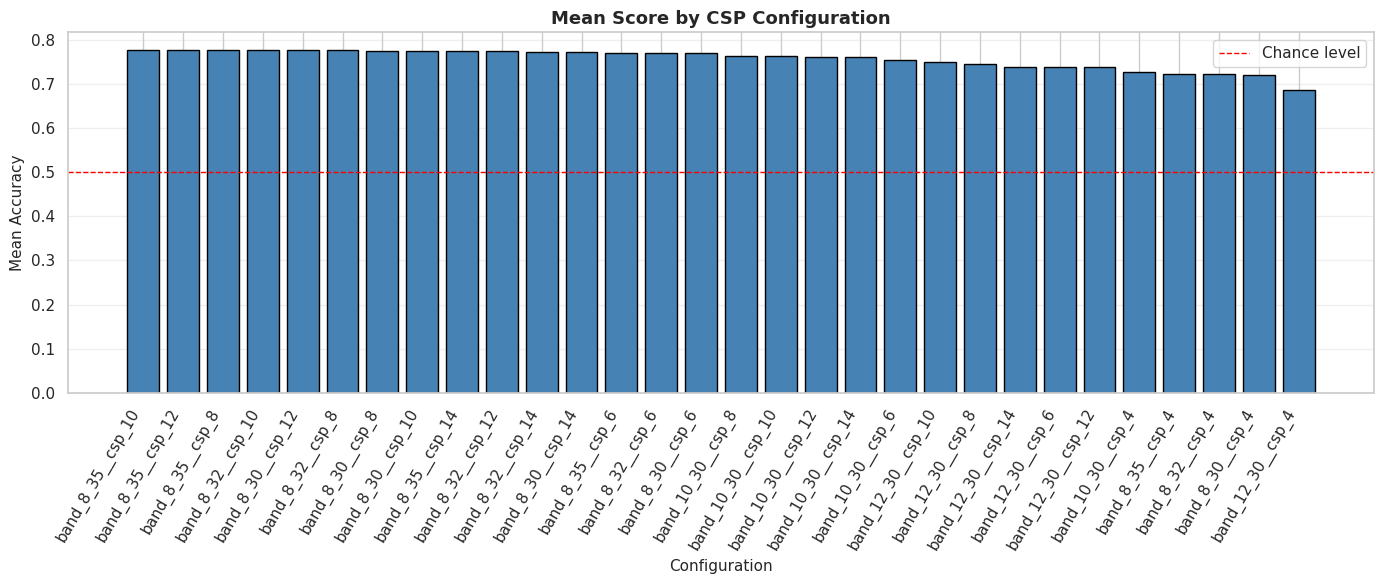

In [9]:
plot_df = config_summary_df.copy()
plot_df = plot_df.sort_values('mean_score', ascending=False)

plt.figure(figsize=(14, 6))
plt.bar(plot_df['config_name'], plot_df['mean_score'], color='steelblue', edgecolor='black')
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Chance level')
plt.xlabel('Configuration', fontsize=11)
plt.ylabel('Mean Accuracy', fontsize=11)
plt.title('Mean Score by CSP Configuration', fontsize=13, fontweight='bold')
plt.xticks(rotation=60, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_plot('mean_score_by_config.png')
plt.show()

[2026-04-15 17:12:18] Saved plot: /home/vegorov/Repos/bci-inefficiency-analysis/src/artifacts/03c_csp_band_tuning/score_heatmap_overall.png


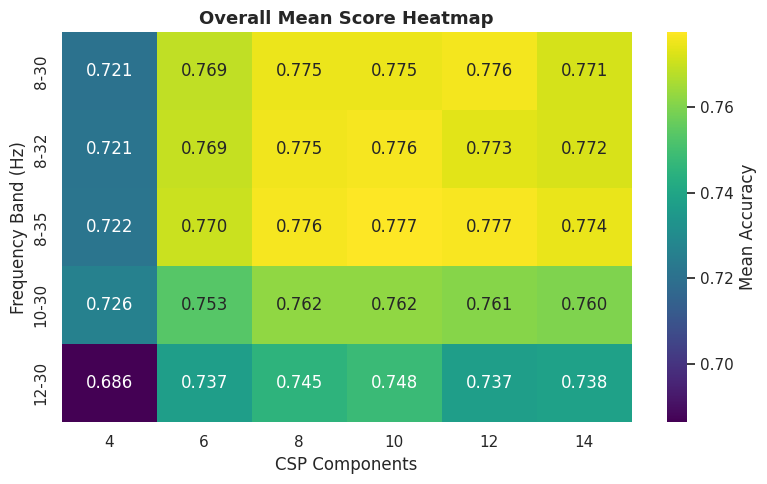

[2026-04-15 17:12:18] Saved plot: /home/vegorov/Repos/bci-inefficiency-analysis/src/artifacts/03c_csp_band_tuning/score_heatmap_bottom2.png


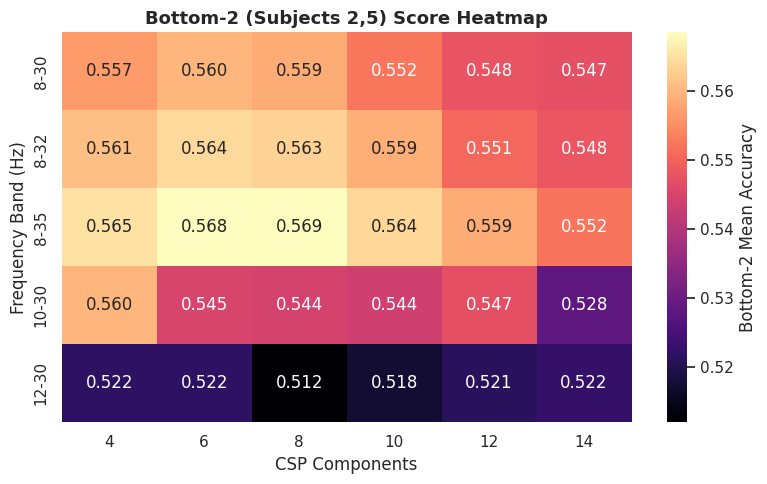

In [10]:
band_order = [f'{low}-{high}' for (low, high) in BANDS]
component_order = CSP_COMPONENTS

overall_heatmap = config_summary_df.pivot(index='band_label', columns='n_components', values='mean_score')
overall_heatmap = overall_heatmap.reindex(index=band_order, columns=component_order)

plt.figure(figsize=(8, 5))
sns.heatmap(overall_heatmap, annot=True, fmt='.3f', cmap='viridis', cbar_kws={'label': 'Mean Accuracy'})
plt.title('Overall Mean Score Heatmap', fontsize=13, fontweight='bold')
plt.xlabel('CSP Components')
plt.ylabel('Frequency Band (Hz)')
plt.tight_layout()
save_plot('score_heatmap_overall.png')
plt.show()

bottom2_heatmap = config_summary_df.pivot(index='band_label', columns='n_components', values='bottom2_mean_score')
bottom2_heatmap = bottom2_heatmap.reindex(index=band_order, columns=component_order)

plt.figure(figsize=(8, 5))
sns.heatmap(bottom2_heatmap, annot=True, fmt='.3f', cmap='magma', cbar_kws={'label': 'Bottom-2 Mean Accuracy'})
plt.title('Bottom-2 (Subjects 2,5) Score Heatmap', fontsize=13, fontweight='bold')
plt.xlabel('CSP Components')
plt.ylabel('Frequency Band (Hz)')
plt.tight_layout()
save_plot('score_heatmap_bottom2.png')
plt.show()

[2026-04-15 17:32:23] Saved plot: /home/vegorov/Repos/bci-inefficiency-analysis/src/artifacts/03c_csp_band_tuning/score_heatmap_subject2.png


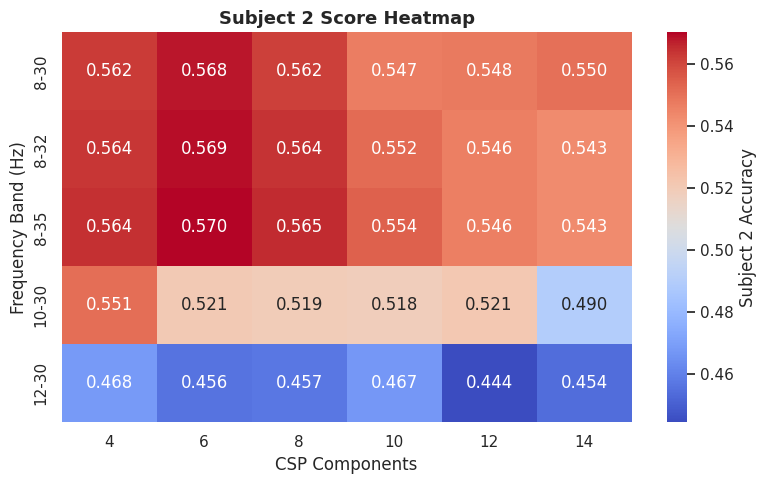

In [14]:
# Score heat map of subject 2 only
subject2_df = per_subject_df[per_subject_df['subject_norm'] == 2]
subject2_heatmap = subject2_df.pivot(index='band_label', columns='n_components', values='score')
subject2_heatmap = subject2_heatmap.reindex(index=band_order, columns=component_order)
plt.figure(figsize=(8, 5))
sns.heatmap(subject2_heatmap, annot=True, fmt='.3f', cmap='coolwarm', cbar_kws={'label': 'Subject 2 Accuracy'})
plt.title('Subject 2 Score Heatmap', fontsize=13, fontweight='bold')
plt.xlabel('CSP Components')
plt.ylabel('Frequency Band (Hz)')
plt.tight_layout()
save_plot('score_heatmap_subject2.png')
plt.show()

[2026-04-15 17:34:53] Saved plot: /home/vegorov/Repos/bci-inefficiency-analysis/src/artifacts/03c_csp_band_tuning/score_heatmap_subject5.png


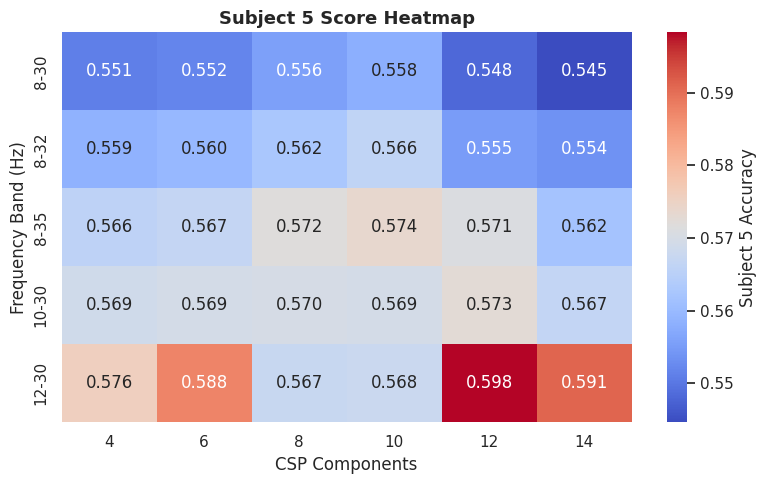

In [15]:
# Score heat map of subject 5 only
subject5_df = per_subject_df[per_subject_df['subject_norm'] == 5]
subject5_heatmap = subject5_df.pivot(index='band_label', columns='n_components', values='score')
subject5_heatmap = subject5_heatmap.reindex(index=band_order, columns=component_order)
plt.figure(figsize=(8, 5))
sns.heatmap(subject5_heatmap, annot=True, fmt='.3f', cmap='coolwarm', cbar_kws={'label': 'Subject 5 Accuracy'})
plt.title('Subject 5 Score Heatmap', fontsize=13, fontweight='bold')
plt.xlabel('CSP Components')
plt.ylabel('Frequency Band (Hz)')
plt.tight_layout()
save_plot('score_heatmap_subject5.png')
plt.show()

[2026-04-15 17:12:19] Saved plot: /home/vegorov/Repos/bci-inefficiency-analysis/src/artifacts/03c_csp_band_tuning/low_subjects_config_response.png


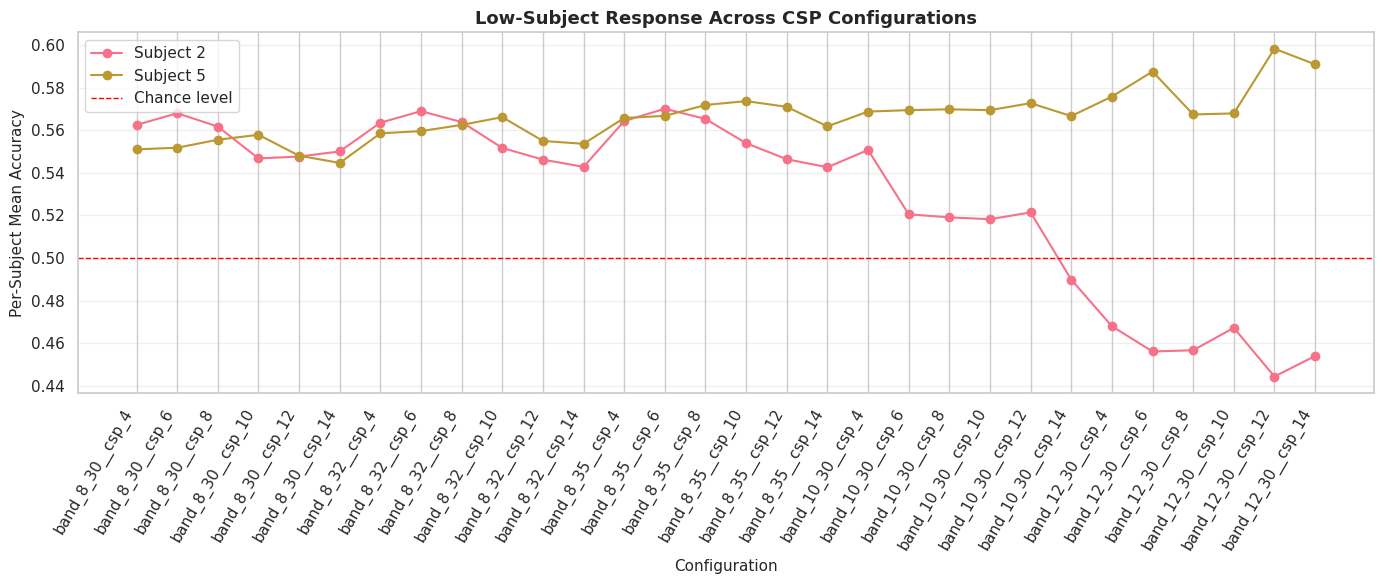

In [11]:
low_subject_plot_df = per_subject_df[per_subject_df['subject_norm'].isin(LOW_SUBJECTS)].copy()

low_subject_plot_df['config_order'] = low_subject_plot_df['config_name'].map(
    {name: idx for idx, name in enumerate(config_summary_df.sort_values(['band_low', 'band_high', 'n_components'])['config_name'].tolist())}
)
low_subject_plot_df = low_subject_plot_df.sort_values(['subject_norm', 'config_order'])

plt.figure(figsize=(14, 6))
for subject_id in LOW_SUBJECTS:
    sdf = low_subject_plot_df[low_subject_plot_df['subject_norm'] == subject_id]
    plt.plot(sdf['config_name'], sdf['score'], marker='o', label=f'Subject {subject_id}')

plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Chance level')
plt.xlabel('Configuration', fontsize=11)
plt.ylabel('Per-Subject Mean Accuracy', fontsize=11)
plt.title('Low-Subject Response Across CSP Configurations', fontsize=13, fontweight='bold')
plt.xticks(rotation=60, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
save_plot('low_subjects_config_response.png')
plt.show()

# 7. Best Configuration Summary

In [12]:
summary_metrics = {
    'best_overall_config_name': best_overall['config_name'],
    'best_overall_band_label': best_overall['band_label'],
    'best_overall_n_components': int(best_overall['n_components']),
    'best_overall_mean_score': float(best_overall['mean_score']),
    'best_overall_std_score': float(best_overall['std_score']),
    'best_overall_min_score': float(best_overall['min_score']),
    'best_overall_max_score': float(best_overall['max_score']),
    'best_bottom2_config_name': best_bottom2['config_name'],
    'best_bottom2_band_label': best_bottom2['band_label'],
    'best_bottom2_n_components': int(best_bottom2['n_components']),
    'best_bottom2_mean_score': float(best_bottom2['bottom2_mean_score']),
    'baseline_mean_reference': float(baseline_mean_reference) if baseline_mean_reference is not None else None,
    'delta_vs_baseline': float(delta_vs_baseline) if not np.isnan(delta_vs_baseline) else None,
}

print('=' * 60)
print('FINAL SUMMARY METRICS')
print('=' * 60)
for k, v in summary_metrics.items():
    print(f'{k}: {v}')

save_table(all_results_df, 'results.csv', index=False)
save_table(config_summary_df, 'config_level_summary.csv', index=False)
save_table(per_subject_best_config_df, 'per_subject_best_config.csv', index=False)
save_table(pd.DataFrame([summary_metrics]), 'summary_metrics.csv', index=False)
save_table(summary_metrics, 'summary_metrics.json', index=False)

print('All required artifacts saved.')

[2026-04-15 17:12:19] ============================================================
[2026-04-15 17:12:19] FINAL SUMMARY METRICS
[2026-04-15 17:12:19] ============================================================
[2026-04-15 17:12:19] best_overall_config_name: band_8_35__csp_10
[2026-04-15 17:12:19] best_overall_band_label: 8-35
[2026-04-15 17:12:19] best_overall_n_components: 10
[2026-04-15 17:12:19] best_overall_mean_score: 0.7773812413215637
[2026-04-15 17:12:19] best_overall_std_score: 0.16206365823745728
[2026-04-15 17:12:19] best_overall_min_score: 0.520061731338501
[2026-04-15 17:12:19] best_overall_max_score: 0.9913194179534912
[2026-04-15 17:12:19] best_bottom2_config_name: band_8_35__csp_8
[2026-04-15 17:12:19] best_bottom2_band_label: 8-35
[2026-04-15 17:12:19] best_bottom2_n_components: 8
[2026-04-15 17:12:19] best_bottom2_mean_score: 0.5685763955116272
[2026-04-15 17:12:19] baseline_mean_reference: None
[2026-04-15 17:12:19] delta_vs_baseline: None
[2026-04-15 17:12:19] Saved